# Switching Performance

**RQ3.** What does runtime model switching cost, and what does it save?

Two cases, identical loop, only the plant exchanged:

- **Full FEM** — the deformable model drives the whole horizon. The reference.
- **Switched FEM/FMU** — the region map hands the horizon between the two models.

Both run `HybridAlgorithm` and therefore pay the same detection overhead. Without
contact the baseline has no indicator of its own, so it is given a constant,
never-crossing one; otherwise it would fall back to `GaussSeidelAlgorithm`, take
no trial advance at all, and the switched case would be charged for work the
reference never does.

Set `CONTACT` below to select the regime. Both were previously separate notebooks
that shared 25 definitions by copy.

In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
from IPython.display import display
from tqdm.auto import tqdm

sys.path.insert(0, str(Path.cwd().resolve().parents[0] / "notebooks"))
sys.path.insert(0, str(Path.cwd().resolve()))

from evidence import repo_root

REPO = repo_root()

import evidence as ev
from plot_setup import FULL_WIDTH, set_professional_style
from record import record, paper_results_dir

# Recorded numbers belong to the paper repository, not to this one.
RESULTS, _results_source = paper_results_dir(REPO)

plt = set_professional_style(latex=True)

print(f"repository root resolved: {REPO.name}")
print(f"results destination      : {_results_source}")

repository root resolved: SystemSimulation
results destination      : sibling SysSimX-Framework-Paper checkout


## Configuration

Every parameter of the run is one `Scenario`. It travels with the run and is
written next to the numbers as provenance, so a recorded result cannot be
separated from the configuration that produced it.

In [2]:
CONTACT = True
SMOKE = True

# Campaign B horizon. evidence_plan.md section 4 requires "well beyond 0.4 s";
# 2.0 is the campaign target. The 2026-09-12 trial runs this contact case once
# to price the horizon and count the contacts before the overnight campaign.
HORIZON_S = 2.0

SCENARIO = ev.CONTACT_SCENARIO if CONTACT else ev.NO_CONTACT_SCENARIO
SCENARIO = SCENARIO.replace(t_end=HORIZON_S)
if SMOKE:
    # Repetitions only. The horizon is NOT shortened: whether the mechanism
    # fires at all depends on it. With the launch gate, the region key only
    # crosses down if |theta| rises slower than gate_offset / gate_t_open
    # (~11.7 rad/s here) *and* the run lasts long enough for |theta| to come
    # back through the band. A 0.1 s smoke horizon silently produced zero
    # switches and a benchmark that measured nothing.
    SCENARIO = SCENARIO.replace(n_warmup=0, n_repeats=1)

# evidence_plan.md section 3: T2 is the runtime table, F5 the runtime
# distribution figure. Both regimes feed the same register rows, so the
# scenario is part of the filename and one does not overwrite the other.
TABLE_ID = f"T2_{SCENARIO.name}"
FIGURE_ID = f"F5_{SCENARIO.name}"
OUT_DIR = REPO / "notebooks" / "figures"
OUT_DIR.mkdir(parents=True, exist_ok=True)

FMU_PATHS = ev.discover_fmus(REPO, sys.platform)

display(pd.Series(SCENARIO.provenance()).to_frame("value"))

,value
name,nocontact
contact,False
t0,0.0
t_end,0.4
macro_dt,0.001
fem_internal_dt,0.001
switch_threshold_rad,0.087266
switch_band_rad,0.017453
region_modes,"[FEM, FMU]"
gate_t_open_s,0.0


## Cases

The baseline is a bare `FEMPendulum`; the switched case is a `SwitchingPendulum`
with the scenario's region map installed. Everything else is shared.

In [3]:
from syssimx_examples.controlled_pendulum.components import FEMPendulum


def build_full_fem():
    plant = FEMPendulum(name=ev.PLANT_NAME, group="Plant")
    plant.set_parameters(**ev.make_fem_parameters(SCENARIO))
    ev.declare_plant_feedthrough(plant)
    system, plant = ev.assemble_system(
        plant, SCENARIO, FMU_PATHS, case_name="Full FEM", detection_probe=True
    )
    return system, plant, {"FEM": plant}


def build_switched():
    plant = ev.SwitchingPendulum(SCENARIO, name=ev.PLANT_NAME).declare_regions()
    plant.set_parameters(**{"FEM": ev.make_fem_parameters(SCENARIO)})
    ev.declare_plant_feedthrough(plant)
    system, plant = ev.assemble_system(
        plant, SCENARIO, FMU_PATHS, case_name="Switched FEM/FMU"
    )
    return system, plant, {"FEM": plant.fem, "FMU": plant.fmu}


CASES = {"Full FEM": build_full_fem, "Switched FEM/FMU": build_switched}

## Execute

Warm-up repetitions are excluded from every summary. The first evaluated
repetition of each case is kept for the figure and the self-checks.

In [4]:
def progress(total, desc):
    return tqdm(total=total, desc=desc, unit=" sim s", leave=False)


rows, kept = [], {}
for repeat in range(SCENARIO.n_warmup):
    for name, builder in CASES.items():
        row, _ = ev.run_measured_case(
            builder, name, repeat, SCENARIO, warmup=True, progress=progress
        )
        rows.append(row)

for repeat in range(SCENARIO.n_repeats):
    for name, builder in CASES.items():
        row, result = ev.run_measured_case(
            builder, name, repeat, SCENARIO,
            keep_result=(repeat == 0), progress=progress,
        )
        rows.append(row)
        if result is not None:
            kept[name] = result

df = pd.DataFrame(rows)
df_eval = df.loc[~df["warmup"]].copy()
print(f"{len(df_eval)} evaluated runs over {SCENARIO.n_repeats} repetitions")

repeat 1 - Full FEM:   0%|          | 0/0.4 [00:00<?, ? sim s/s]

repeat 1 - Switched FEM/FMU:   0%|          | 0/0.4 [00:00<?, ? sim s/s]

repeat 2 - Full FEM:   0%|          | 0/0.4 [00:00<?, ? sim s/s]

repeat 2 - Switched FEM/FMU:   0%|          | 0/0.4 [00:00<?, ? sim s/s]

4 evaluated runs over 2 repetitions


## Self-checks

A benchmark that silently stopped exercising the mechanism still produces a
speedup number. These raise rather than warn.

In [9]:
switched = kept["Switched FEM/FMU"]
baseline = kept["Full FEM"]

if df_eval.loc[df_eval["case"] == "Switched FEM/FMU", "n_switches"].min() == 0:
    # Say why, rather than only that. The two causes are a horizon that ends
    # before the key re-enters the band, and a launch fast enough that the gated
    # key never leaves the upper region in the first place.
    key_trace = np.abs(switched["theta"]) + SCENARIO.gate_offset_rad * np.clip(
        1.0 - switched["t"] / max(SCENARIO.gate_t_open_s, 1e-12), 0.0, None
    ) if SCENARIO.gated else np.abs(switched["theta"])
    boundary_events = {
        name: len(records)
        for (_c, name), records in switched.get("event_history", {}).items()
        if name.startswith("region_boundary_")
    }
    raise AssertionError(
        "The switched case never left its initial model, so this run measures "
        "nothing about switching.\n"
        f"  reconciled initial mode : {switched['initial_mode']}\n"
        f"  horizon                 : {SCENARIO.t0} .. {SCENARIO.t_end} s\n"
        f"  region key min / max    : {key_trace.min():.4f} / {key_trace.max():.4f} rad\n"
        f"  armed edges             : {SCENARIO.armed_lower_edge:.4f} / "
        f"{SCENARIO.armed_upper_edge:.4f} rad\n"
        f"  region boundary events  : {boundary_events or 'none'}\n"
        "If the key never reaches an armed edge, either the horizon is too short "
        "or the launch is too fast for the gate: the key only crosses down while "
        "|theta| rises slower than gate_offset / gate_t_open."
    )

if SCENARIO.contact:
    counts = df_eval.groupby("case")["n_contacts"].apply(lambda s: sorted(set(s))).to_dict()
    print("contacts per case:", counts)
    if min(min(v) for v in counts.values()) == 0:
        raise AssertionError(
            "No wall contact was resolved. The pendulum starts on the wall_hit zero, so a first "
            "step onto the negative side leaves the falling indicator unable to fire (HYB-01)."
        )
    if len(baseline["contact_times"]) != len(switched["contact_times"]):
        raise AssertionError(
            f"Contact counts differ: {len(baseline['contact_times'])} vs "
            f"{len(switched['contact_times'])}. The runs are on different bounce sequences, so "
            f"any trajectory comparison would compare unlike physics."
        )
    offsets = np.abs(np.array(switched["contact_times"]) - np.array(baseline["contact_times"]))
    gaps = np.diff(baseline["contact_times"])
    mean_interval = float(np.mean(gaps)) if gaps.size else float("inf")
    print(f"max contact-instant offset : {offsets.max():.2e} s "
          f"({offsets.max() / SCENARIO.macro_dt:.1f} macro steps)")
    if offsets.max() > 0.5 * mean_interval:
        raise AssertionError("Contact instants differ by more than half the mean bounce interval.")

if SCENARIO.gated:
    # The launch gate must not drive a switch on its own. The run starts in the
    # outer region, whose armed threshold is the lower band edge, so the gated
    # key has to stay above that edge for the whole ramp.
    t = switched["t"]
    ramp = t <= SCENARIO.gate_t_open_s
    key = np.abs(switched["theta"][ramp]) + SCENARIO.gate_offset_rad * np.clip(
        1.0 - t[ramp] / SCENARIO.gate_t_open_s, 0.0, None
    )
    print(f"gated key minimum over ramp: {key.min():.4f} rad "
          f"(armed edge {SCENARIO.armed_lower_edge:.4f} rad)")
    if key.size and key.min() <= SCENARIO.armed_lower_edge:
        raise AssertionError(
            "The gated key falls to the armed edge during the ramp, so the ramp itself triggers "
            "the switch and the model choice encodes this trajectory's schedule."
        )

print("OK: the mechanism was exercised and the two cases are comparable.")

OK: the mechanism was exercised and the two cases are comparable.


## Result

`run_speedup` is the headline. `accepted_speedup` divides out the detection
overhead that both cases pay, and should track the inverse FEM duty cycle: if the
FEM is active for a fraction *f* of the horizon and dominates the cost, accepted
model time scales with *f*. `discarded` is the share of model time that is
computed and rolled back — a property of hybrid detection, not of switching.

In [10]:
paired = df_eval.pivot(index="repeat", columns="case", values="run_s")
ratio = paired["Full FEM"] / paired["Switched FEM/FMU"]

summary = df_eval.groupby("case", sort=False).agg(
    run_s=("run_s", "median"),
    solve_s=("solve_s", "median"),
    accepted_s=("solve_accepted_s", "median"),
    overhead_s=("overhead_s", "median"),
    fem_active_sim_s=("fem_active_sim_s", "median"),
    n_switches=("n_switches", "median"),
)
ref = summary.loc["Full FEM"]
summary["run_speedup"] = ref["run_s"] / summary["run_s"]
summary["accepted_speedup"] = ref["accepted_s"] / summary["accepted_s"]
summary["overhead_share"] = summary["overhead_s"] / summary["run_s"]
summary["fem_duty"] = summary["fem_active_sim_s"] / SCENARIO.sim_time

discarded = {
    case: float(
        sum(sub[f"solve_{p}_s"].median() for p in ev.DISCARDED_PHASES)
        / max(sub["solve_s"].median(), 1e-12)
    )
    for case, sub in df_eval.groupby("case", sort=False)
}
summary["discarded"] = pd.Series(discarded)

display(summary.style.format({
    "run_s": "{:.2f}", "solve_s": "{:.2f}", "accepted_s": "{:.2f}",
    "overhead_s": "{:.3f}", "fem_active_sim_s": "{:.3f}", "n_switches": "{:.0f}",
    "run_speedup": "{:.2f}x", "accepted_speedup": "{:.2f}x",
    "overhead_share": "{:.1%}", "fem_duty": "{:.1%}", "discarded": "{:.1%}",
}))

print(f"paired run speedup : median {ratio.median():.2f}x  "
      f"spread {ratio.max() - ratio.min():.2f}")
print(f"1 / FEM duty cycle : {1.0 / summary.loc['Switched FEM/FMU', 'fem_duty']:.2f}x "
      f"(expected accepted speedup)")

,run_s,solve_s,accepted_s,overhead_s,fem_active_sim_s,n_switches,run_speedup,accepted_speedup,overhead_share,fem_duty,discarded
case,,,,,,,,,,,
Full FEM,84.11,74.84,35.95,9.277,0.400,0,1.00x,1.00x,11.0%,100.0%,52.0%
Switched FEM/FMU,21.56,16.85,7.38,4.713,0.079,5,3.90x,4.87x,21.9%,19.7%,56.2%


paired run speedup : median 3.90x  spread 0.45
1 / FEM duty cycle : 5.08x (expected accepted speedup)


In [11]:
record(
    TABLE_ID,
    {
        "run_speedup_paired_median": float(ratio.median()),
        "run_speedup_paired": [float(v) for v in ratio],
        "accepted_speedup": float(summary.loc["Switched FEM/FMU", "accepted_speedup"]),
        "fem_duty_cycle": float(summary.loc["Switched FEM/FMU", "fem_duty"]),
        "overhead_share": {k: float(v) for k, v in summary["overhead_share"].items()},
        "discarded_model_time": {k: float(v) for k, v in summary["discarded"].items()},
        "n_switches": int(summary.loc["Switched FEM/FMU", "n_switches"]),
        "run_s_median": {k: float(v) for k, v in summary["run_s"].items()},
        "scenario": SCENARIO.provenance(),
    },
    directory=RESULTS,
    notebook="04_performance",
    smoke=SMOKE,
)

WindowsPath('C:/Users/flori/source/repos/FlorianFrech/SysSimX-Framework-Paper/results/T2_nocontact.smoke.json')

## Figure

One panel: where the wall time goes in each case, split by algorithm phase, with
orchestration on top. The discarded phases are what the hybrid scheme computes
and throws away; they are present with and without switching.

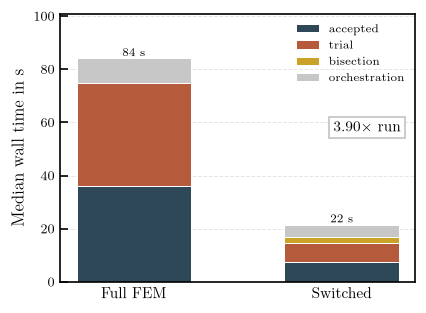

In [12]:
PHASE_COLORS = {
    ev.ACCEPTED: "#2F4858", ev.TRIAL: "#B65A3C", ev.BISECTION: "#C9A227",
    ev.EVENTS: "#7B6D8D", ev.OTHER: "#9AA5A8",
}

cases = list(summary.index)
x = np.arange(len(cases))
bottom = np.zeros(len(cases))

fig, ax = plt.subplots(figsize=(0.62 * FULL_WIDTH, 0.46 * FULL_WIDTH))

for phase in ev.PHASES:
    values = np.array([
        float(df_eval.loc[df_eval["case"] == c, f"solve_{phase}_s"].median()) for c in cases
    ])
    if not np.any(values > 0):
        continue
    ax.bar(x, values, bottom=bottom, width=0.55, color=PHASE_COLORS[phase],
           label=phase, edgecolor="white", linewidth=0.6)
    bottom += values

overhead = np.array([float(summary.loc[c, "overhead_s"]) for c in cases])
ax.bar(x, overhead, bottom=bottom, width=0.55, color="0.78",
       label="orchestration", edgecolor="white", linewidth=0.6)
bottom += overhead

for xi, total in zip(x, bottom):
    ax.text(xi, total, f"{total:.0f} s", ha="center", va="bottom", fontsize=7)

ax.set_xticks(x)
ax.set_xticklabels(["Full FEM", "Switched"], fontsize=9)
ax.set_ylabel(r"Median wall time in $\mathrm{s}$")
ax.set_ylim(0, bottom.max() * 1.2)
ax.grid(True, axis="y", alpha=0.4)
ax.legend(loc="upper right", fontsize=7, frameon=False)
ax.text(0.96, 0.60, rf"${ratio.median():.2f}\times$ run",
        transform=ax.transAxes, ha="right", va="top", fontsize=9,
        bbox=dict(facecolor="white", edgecolor="0.75", alpha=0.95, pad=2.5))

fig.tight_layout()
fig.savefig(OUT_DIR / f"{FIGURE_ID}.pdf", bbox_inches="tight")
plt.show()

## Reading the result

Read the table, not any number written into this prose; absolute timings move
with machine state and are only comparable within one `Scenario`.

**The discarded share is a detection cost, not a switching cost.** A configuration
that never switches discards essentially the same fraction as one that does.
`_detect_crossings` advances every event source across the macro step and
restores it; if no crossing is found, Gauss-Seidel then steps the same interval
again, so an event-free macro step solves the model twice for one result. That is
`issues.md` EVID-01 and HYB-03.

**Bisection cost depends on whether the component reports its own bracket.** With
contact, `FEMPendulum` reduces its sub-step near the wall and reports the
bracketing interval, which `_locate_event_time` accepts directly when `tol_time`
is coarser than that sub-step. Without contact there is no hint and every switch
is localized by bisection. The two regimes bracket what that shortcut is worth.

**The saving is bounded by the duty cycle.** Compare `accepted_speedup` against
`1 / fem_duty`. A large gap means something other than the model choice is driving
the number.